## This notebook will contain the EDA for the OLIST dataset

In [63]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\marco\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [64]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

# load datasets
orders = pd.read_csv('../data/olist_dataset/olist_orders_dataset.csv')
customers = pd.read_csv('../data/olist_dataset/olist_customers_dataset.csv')

# Check data
orders.head()
orders.info()
orders.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


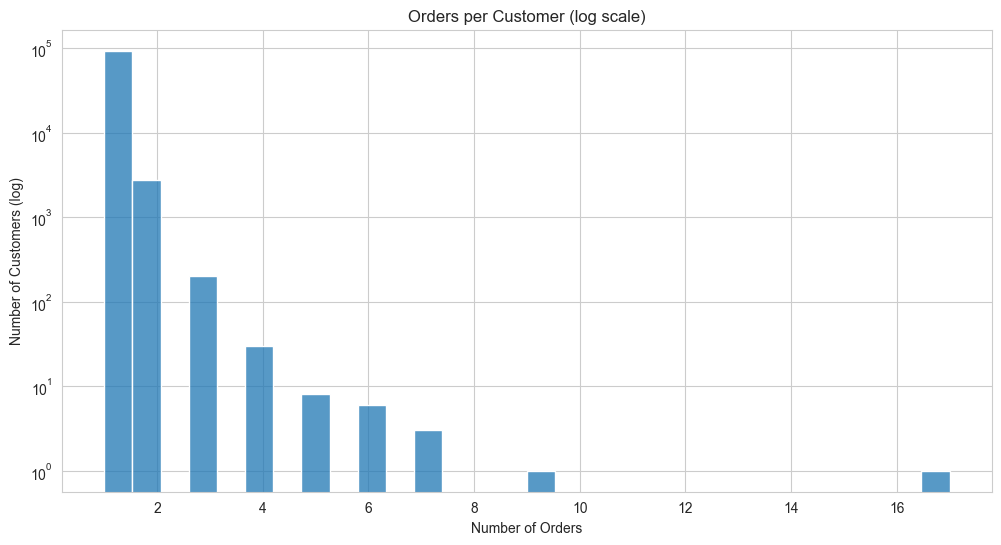

In [65]:
# Number of orders per customer
orders_per_customer = (
    orders
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id')
    .groupby('customer_unique_id')['order_id']
    .count()
)
sns.histplot(orders_per_customer, bins=30)
plt.yscale('log')
plt.title('Orders per Customer (log scale)')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers (log)')
plt.show()

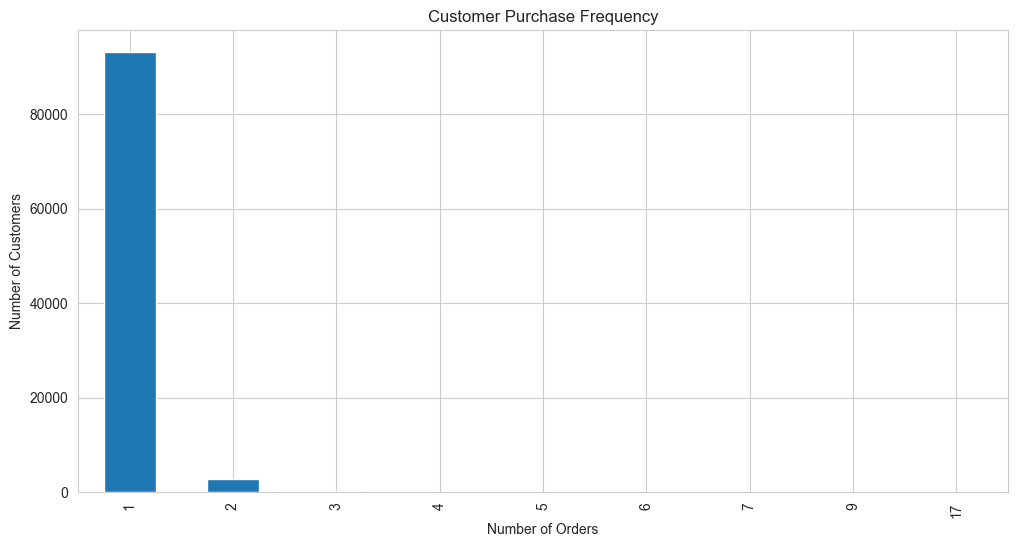

In [66]:
orders_per_customer.value_counts().sort_index().head(10).plot(kind='bar')
plt.title('Customer Purchase Frequency')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.show()

## What did we just see?

The results show that the majority of customers make only a single purchase.
When visualized on a logarithmic scale, it becomes evident that repeat buyers
represent a very small fraction of the customer base.

This pattern indicates low customer retention and highlights a significant
opportunity to improve business outcomes through targeted retention strategies
and data-driven decision-making.

## Churn

Churn refers to customers who stop interacting with a product or service for
a defined period of time. This is a critical business problem, as retaining
existing customers is generally more cost-effective than acquiring new ones.

Customer churn can be driven by multiple factors, including:
- Poor user experience
- Product limitations or misalignment with customer needs
- Pricing issues
- Ineffective timing or communication strategies

In this project, we identify churned customers based on their purchase
recency and analyze behavioral patterns using RFM metrics, with the goal of
supporting data-driven retention strategies.


In [67]:
orders_delivered = orders[
    orders['order_status'] == 'delivered'
][['order_id', 'customer_id', 'order_purchase_timestamp']].copy()

orders_delivered['order_purchase_timestamp'] = pd.to_datetime(
    orders_delivered['order_purchase_timestamp']
)
reference_date = orders_delivered['order_purchase_timestamp'].max()
reference_date
rfm = (
    orders_delivered
    .groupby('customer_id')
    .agg(
        recency_days=('order_purchase_timestamp',
                       lambda x: (reference_date - x.max()).days),
        frequency=('order_id', 'count')
    )
    .reset_index()
)

rfm.head()


,customer_id,recency_days,frequency
0,00012a2ce6f8dcda20d059ce98491703,287,1
1,000161a058600d5901f007fab4c27140,409,1
2,0001fd6190edaaf884bcaf3d49edf079,547,1
3,0002414f95344307404f0ace7a26f1d5,378,1
4,000379cdec625522490c315e70c7a9fb,149,1


In [68]:
# Describing the recency days for further analysis
rfm['recency_days'].describe(
    percentiles=[0.5, 0.6, 0.7, 0.8, 0.9]
)


count    96478.000000
mean       239.121364
std        152.836972
min          0.000000
50%        220.000000
60%        269.000000
70%        315.000000
80%        384.000000
90%        466.000000
max        713.000000
Name: recency_days, dtype: float64

## Churn Definition and Labeling Strategy

To transform the business problem into a supervised learning task, we first need
to define what churn means in this context.

Rather than adopting an arbitrary time window, we analyze the empirical
distribution of customer recency to ensure that the churn definition reflects
actual customer behavior observed in the data.

### Target Period

Based on the recency distribution, we define a customer as **churned** if they do
not place a new order within **315 days** after their last purchase. This value
corresponds to the **70th percentile** of the recency distribution.

This threshold captures customers whose inactivity is significantly longer than
the typical repurchase cycle, while avoiding the misclassification of customers
with naturally long purchase intervals.

### Churn Label

- **Churn = 1** → Customer did not make any new purchases within 315 days  
- **Churn = 0** → Customer made at least one purchase within 315 days  

This binary definition allows us to frame churn prediction as a classification
problem grounded in real behavioral patterns.


## Feature Engineering – RFM Framework

To capture customer purchasing behavior in a structured way, we apply the **RFM framework**, a widely used methodology in customer analytics and retention modeling.

- **Recency (R):** How many days have passed since the customer's last purchase  
- **Frequency (F):** How many orders the customer has placed  
- **Monetary (M):** How much the customer has spent in total  

These features help quantify customer engagement and are strong predictors of churn.


C:\Users\marco\AppData\Local\Temp\ipykernel_9164\3096017593.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_delivered['order_purchase_timestamp'] = pd.to_datetime(


Text(0.5, 1.0, 'RFM Analysis: Recency vs Frequency')

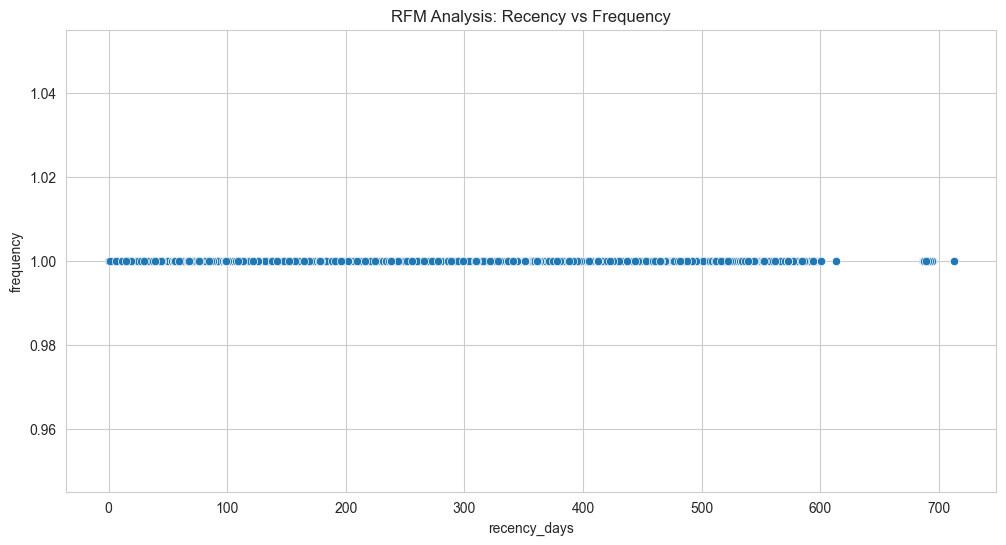

In [69]:
import pandas as pd

# Filter delivered orders only
orders_delivered = orders[orders['order_status'] == 'delivered']

# Convert order purchase timestamp to datetime
orders_delivered['order_purchase_timestamp'] = pd.to_datetime(
    orders_delivered['order_purchase_timestamp']
)

# Reference date: last order in dataset
reference_date = orders_delivered['order_purchase_timestamp'].max()

# RFM aggregation
rfm = orders_delivered.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,  # Recency
    'order_id': 'count'  # Frequency
}).reset_index()

rfm.rename(columns={
    'order_purchase_timestamp': 'recency_days',
    'order_id': 'frequency'
}, inplace=True)

rfm.head()
sns.scatterplot(data=rfm, x='recency_days', y='frequency')
plt.title('RFM Analysis: Recency vs Frequency')

In [70]:
rfm = rfm.drop(columns=['monetary'], errors='ignore')

order_payments = pd.read_csv('../data/olist_dataset/olist_order_payments_dataset.csv')

monetary = order_payments.merge(
    orders_delivered[['order_id', 'customer_id']],
    on='order_id',
    how='inner'
).groupby('customer_id')['payment_value'].sum().reset_index()

monetary.rename(columns={'payment_value': 'monetary'}, inplace=True)

rfm = rfm.merge(monetary, on='customer_id', how='left')
rfm['monetary'] = rfm['monetary'].fillna(0)
rfm.head()

,customer_id,recency_days,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,287,1,114.74
1,000161a058600d5901f007fab4c27140,409,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,547,1,195.42
3,0002414f95344307404f0ace7a26f1d5,378,1,179.35
4,000379cdec625522490c315e70c7a9fb,149,1,107.01


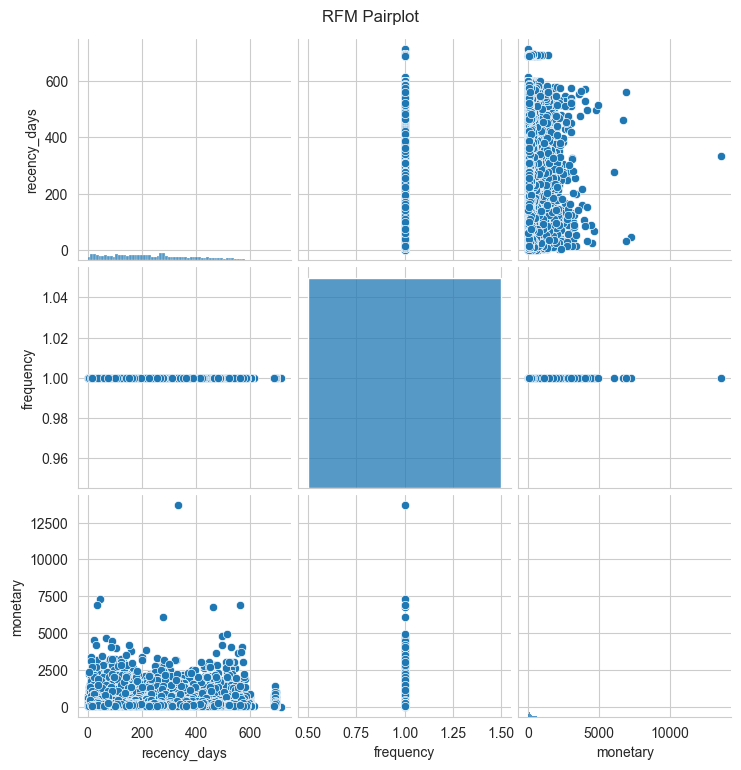

In [71]:
# Defining the churned customers
CHURN_THRESHOLD = 315 #75 percentile
rfm['churn'] = (rfm['recency_days'] > CHURN_THRESHOLD).astype(int)
sns.pairplot(rfm[['recency_days', 'frequency', 'monetary']])
plt.suptitle('RFM Pairplot', y=1.02)
plt.show()


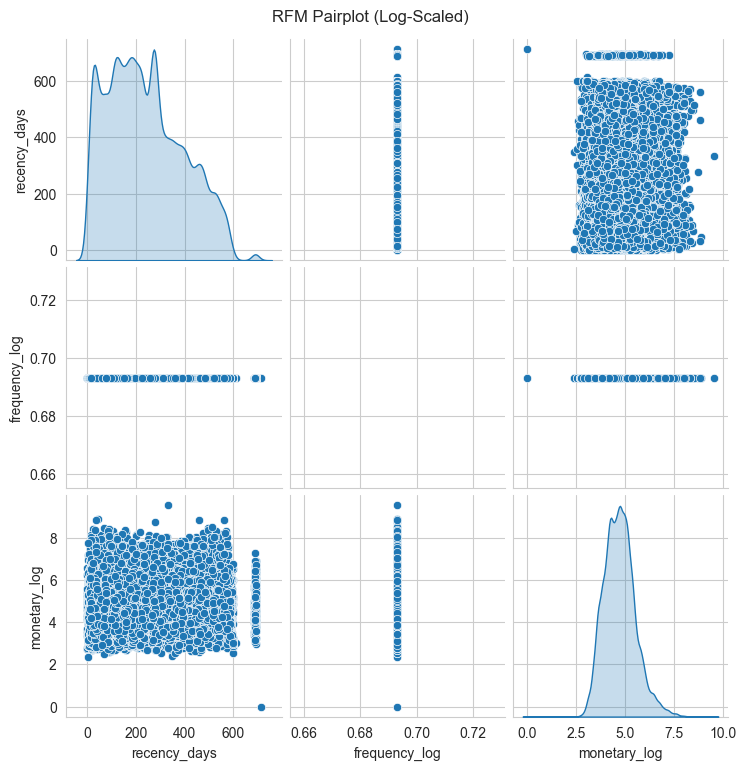

In [72]:
# Pairplot with log scale
rfm_log = rfm.copy()
rfm_log['frequency_log'] = np.log1p(rfm_log['frequency'])
rfm_log['monetary_log'] = np.log1p(rfm_log['monetary'])

sns.pairplot(
    rfm_log[['recency_days', 'frequency_log', 'monetary_log']],
    diag_kind='kde'
)
plt.suptitle('RFM Pairplot (Log-Scaled)', y=1.02)
plt.show()


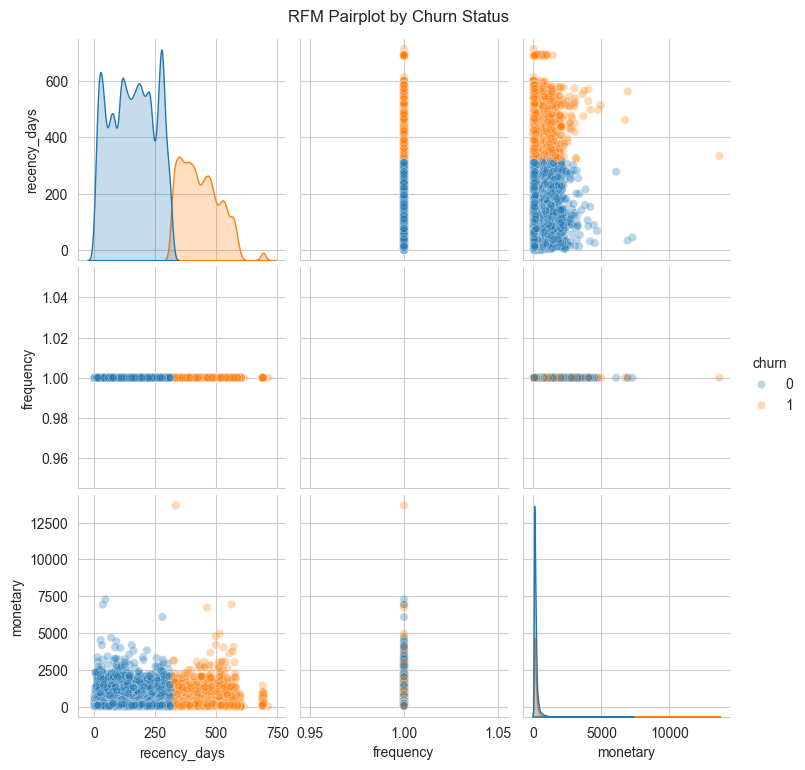

In [73]:
# Churn pairplot
sns.pairplot(
    rfm,
    vars=['recency_days', 'frequency', 'monetary'],
    hue='churn',
    plot_kws={'alpha': 0.3},
    diag_kind='kde'
)
plt.suptitle('RFM Pairplot by Churn Status', y=1.02)
plt.show()

# Churn definition:
# Customers are labeled as churned (churn = 1) if they have been inactive
# for more than 315 days. This threshold reflects a business-driven definition
# of customer inactivity commonly used in ecommerce and retention analysis.
# Active customers are labeled as churn = 0.

## Diagnosis

The analysis shows that churned customers tend to have higher total monetary
values than active customers. This does not indicate higher loyalty, but rather
suggests that many churned users make high-value, one-time purchases and do not
return afterward.

To better understand this behavior, we analyze the types of products purchased
by churned and active customers.


In [74]:
order_items = pd.read_csv('../data/olist_dataset/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_dataset/olist_products_dataset.csv')

# Merge order_items with products
order_items_products = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# Attach customer_id and churn
order_items_products = order_items_products.merge(
    orders_delivered[['order_id', 'customer_id']],
    on='order_id',
    how='left'
)

order_items_products = order_items_products.merge(
    rfm[['customer_id', 'churn']],
    on='customer_id',
    how='left'
)

order_items_products.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,customer_id,churn
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,3ce436f183e68e07877b285a838db11a,1.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,1.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,6489ae5e4333f3693df5ad4372dab6d3,0.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,d4eb9395c8c0431ee92fce09860c5a06,0.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,58dbd0b2d70206bf40e62cd34e84d795,1.0


In [75]:
# Top categories by churn status x non churn
category_churn = (
    order_items_products
    .groupby(['churn', 'product_category_name'])
    .size()
    .reset_index(name='count')
)

category_churn.head()


,churn,product_category_name,count
0,0.0,agro_industria_e_comercio,178
1,0.0,alimentos,415
2,0.0,alimentos_bebidas,207
3,0.0,artes,169
4,0.0,artes_e_artesanato,22


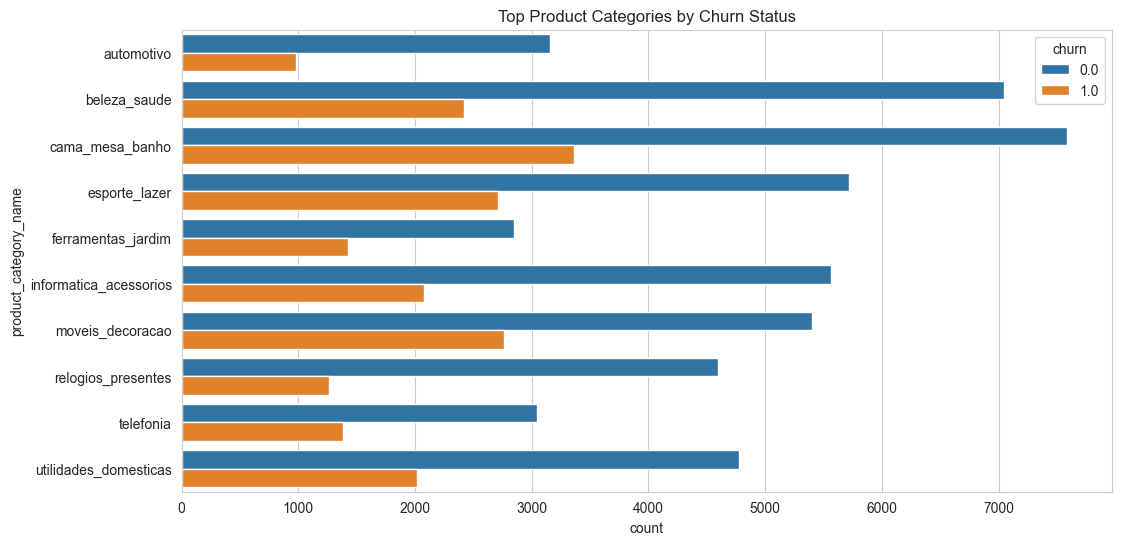

In [76]:
top_categories = (
    category_churn
    .groupby('product_category_name')['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

sns.barplot(
    data=category_churn[category_churn['product_category_name'].isin(top_categories)],
    x='count',
    y='product_category_name',
    hue='churn'
)
plt.title('Top Product Categories by Churn Status')
plt.show()


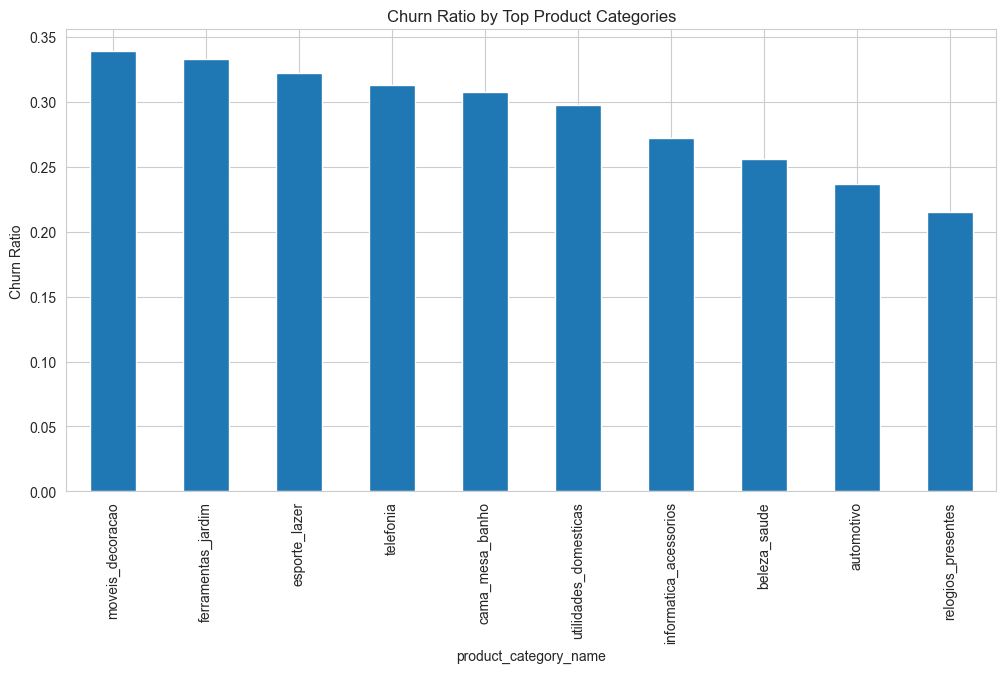

In [77]:
# Plotting the ratio of churned to non-churned customers per top category
category_pivot = category_churn.pivot(
    index='product_category_name',
    columns='churn',
    values='count'
).fillna(0)
category_pivot = category_pivot.loc[top_categories]
category_pivot['churn_ratio'] = category_pivot[1] / (category_pivot[0] + category_pivot[1])
category_pivot = category_pivot.sort_values(by='churn_ratio', ascending=False)
category_pivot[['churn_ratio']].plot(
    kind='bar',
    legend=False
)
plt.title('Churn Ratio by Top Product Categories')
plt.ylabel('Churn Ratio')   
plt.show()

## Insights
The churn ratio by product category reveals a clear behavioral pattern.
Categories with the highest churn ratios are primarily composed of durable
goods (e.g., furniture, electronics, garden products), which naturally have
long replacement cycles and low repurchase frequency.

On the other hand, categories such as beauty and health show significantly
lower churn ratios, likely due to their consumable nature and shorter
replenishment cycles.

This suggests that a substantial portion of customer churn is structural
and category-driven, rather than solely a result of poor customer experience.

In [78]:
# Creating durable category feature
durable_categories = [
    'moveis', 'informatica', 'telefonia', 'jardim',
    'esporte_lazer', 'automotivo'
]

rfm['durable_category'] = rfm['customer_id'].isin(
    order_items_products[
        order_items_products['product_category_name'].isin(durable_categories)
    ]['customer_id']
).astype(int)
rfm.groupby('durable_category')['churn'].mean()
rfm.head()

,customer_id,recency_days,frequency,monetary,churn,durable_category
0,00012a2ce6f8dcda20d059ce98491703,287,1,114.74,0,0
1,000161a058600d5901f007fab4c27140,409,1,67.41,1,0
2,0001fd6190edaaf884bcaf3d49edf079,547,1,195.42,1,0
3,0002414f95344307404f0ace7a26f1d5,378,1,179.35,1,0
4,000379cdec625522490c315e70c7a9fb,149,1,107.01,0,0


In [79]:
rfm.groupby('durable_category')['churn'].mean()


durable_category
0    0.299416
1    0.294808
Name: churn, dtype: float64